In [3]:

# ── Imports ────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from sklearn.cluster import DBSCAN


In [1]:

# ── Constants ──────────────────────────────────────────────────────────────────
ROOT = "../../"

# Input paths
PARCEL_SHP      = ROOT + "data/geo/Parcels_7711352183771741448/Parcel_Boundaries.shp"
BUSINESS_XLSX   = ROOT + "data/business/Oakland_DataAxleV2.xlsx"

# Corridor shapefiles
OAK_BIDS_SHP        = ROOT + "data/corridors/OAK_BIDs/OAK_BIDs.shp"
POLICY_POLYGONS_SHP = ROOT + "data/corridors/Policy_Polygons/Policy_Polygons.shp"

# Output paths
OUT_DIR         = ROOT + "data/corridors/parcels/"
OUT_USE_CODE    = OUT_DIR + "parcels_use_code_filtered.gpkg"
OUT_BIZ_CONTAIN = OUT_DIR + "parcels_with_business.gpkg"
OUT_UNION       = OUT_DIR + "parcels_union.gpkg"

# Use code prefixes to keep (3xxx, 8xxx, 9xxx)
USE_CODE_PREFIXES = ("3", "8", "9")

# Coordinate reference systems
PARCEL_CRS   = "EPSG:3857"   # Web Mercator (native CRS of the parcel shapefile)
BUSINESS_CRS = "EPSG:4326"   # WGS 84 (lat/lon of the business data)
CORRIDOR_CRS = "EPSG:4269"   # NAD 83 (native CRS of the corridor shapefiles)

# ── Section 3 — corridor methodology parameters ────────────────────────────────

# Geographic stratification grid (shared by Approaches A & B)
# Divides the study bounding box into zones to prevent downtown Oakland from
# dominating results in density-based methods.
SUBREGION_ROWS    = 3     # N–S divisions of the study bounding box
SUBREGION_COLS    = 2     # E–W divisions of the study bounding box

# Approach A: DBSCAN clustering of business points (sub-region stratified)
DBSCAN_EPS_M          = 200   # neighbourhood radius in metres
DBSCAN_MIN_SAMPLES    = 8     # minimum points to form a core point
DBSCAN_MIN_CLUSTER_N  = 15    # drop clusters with fewer businesses than this
DBSCAN_BIZ_BUFFER_M   = 80    # buffer around each point when building cluster footprint

# Approach B: Grid-density thresholding (local-relative)
GRID_CELL_SIZE_M      = 350   # fishnet cell width/height in metres
GRID_PERCENTILE       = 70    # keep cells in the top (100−70)=30% of their sub-region
GRID_BIZ_THRESHOLD    = 4     # absolute floor: cells must still have ≥ this many businesses
GRID_MIN_CELLS        = 3     # minimum cells in a dissolved blob to keep

# Approach C: Parcel-connectivity blobs + spatial-diversity selection
PARCEL_CONNECT_BUF_M  = 40    # buffer to bridge adjacent parcels before dissolve
BLOB_MIN_PARCELS      = 25    # minimum union parcels in a blob to keep
TARGET_CORRIDORS      = 25    # approximate number of corridors to select
MIN_SPACING_M         = 3000  # minimum centroid-to-centroid distance between selections



# Section 1 — Identify Preliminary Corridor Parcels

This section filters the Alameda County parcel dataset to produce three targeted parcel layers,
all saved as GeoPackage files under `data/corridors/parcels/`:

| Output file | Description |
|---|---|
| `parcels_use_code_filtered.gpkg` | Parcels whose `UseCode` starts with 3, 8, or 9 (commercial / industrial / special use) |
| `parcels_with_business.gpkg` | Parcels that contain at least one DataAxle business centroid |
| `parcels_union.gpkg` | Union of the two filtered sets (deduplicated) |



## 1.1 Load Parcel Data

Read the full Alameda County parcel shapefile into a GeoDataFrame.  
The native CRS is **EPSG:3857** (Web Mercator).


In [4]:

# Load full parcel shapefile (~1 GB on disk; reads into memory as a GeoDataFrame)
parcels = gpd.read_file(PARCEL_SHP)

print(f"Total parcels loaded : {len(parcels):,}")
print(f"CRS                  : {parcels.crs}")
print(f"UseCode sample values: {parcels['UseCode'].dropna().unique()[:10]}")


Total parcels loaded : 489,576
CRS                  : EPSG:3857
UseCode sample values: ['1100' '0800' '3600' '0500' '0300' '8300' '4100' '4102' '2500' '3000']



## 1.2 Filter Parcels by Use Code (3xxx / 8xxx / 9xxx)

Retain only parcels whose 4-digit `UseCode` begins with **3** (commercial),
**8** (institutional / public), or **9** (miscellaneous / special).  
The result is saved to `parcels_use_code_filtered.gpkg`.


In [5]:

# Cast UseCode to string and normalise to 4 characters (zero-pad if needed),
# then keep rows whose first character matches one of the target prefixes.
parcels["UseCode_str"] = (
    parcels["UseCode"]
    .astype(str)
    .str.strip()
    .str.zfill(4)
)

mask_use_code = parcels["UseCode_str"].str[0].isin(list(USE_CODE_PREFIXES))
parcels_use_code = parcels[mask_use_code].copy()

print(f"Parcels matching 3xxx/8xxx/9xxx use codes : {len(parcels_use_code):,}")
print(parcels_use_code["UseCode_str"].value_counts().head(15))

# Save to GeoPackage
os.makedirs(OUT_DIR, exist_ok=True)
parcels_use_code.to_file(OUT_USE_CODE, driver="GPKG")
print(f"\nSaved → {OUT_USE_CODE}")


Parcels matching 3xxx/8xxx/9xxx use codes : 15,038
UseCode_str
3100    2361
3200    1961
9400    1475
3000     948
3900     856
8100     813
9300     676
8300     668
3600     642
3300     606
9401     523
9901     517
3700     456
8500     395
8200     222
Name: count, dtype: int64

Saved → ../../data/corridors/parcels/parcels_use_code_filtered.gpkg



## 1.3 Load Business Data and Build GeoDataFrame

Read the DataAxle business registry from the Excel file.  
`Latitude` / `Longitude` are in **WGS 84 (EPSG:4326)**, so we construct point
geometries and then reproject to match the parcel CRS (**EPSG:3857**) before
performing the spatial join.


In [6]:

# Load business registry (only need the coordinate columns for spatial work)
businesses_df = pd.read_excel(BUSINESS_XLSX)

# Drop rows that have no usable coordinates
businesses_df = businesses_df.dropna(subset=["Latitude", "Longitude"])

print(f"Businesses with valid coordinates : {len(businesses_df):,}")

# Build GeoDataFrame — points from lat/lon (WGS 84)
businesses_gdf = gpd.GeoDataFrame(
    businesses_df,
    geometry=gpd.points_from_xy(businesses_df["Longitude"], businesses_df["Latitude"]),
    crs=BUSINESS_CRS,
)

# Reproject to the same CRS as the parcel layer (EPSG:3857)
businesses_gdf = businesses_gdf.to_crs(PARCEL_CRS)

print(f"Business CRS after reprojection   : {businesses_gdf.crs}")


Businesses with valid coordinates : 29,545
Business CRS after reprojection   : EPSG:3857



## 1.4 Filter Parcels That Contain a Business Centroid

Use a spatial join (`predicate="contains"`) to find every parcel polygon that
contains at least one business point.  We then deduplicate by parcel index so
each parcel appears only once regardless of how many businesses it contains.  
The result is saved to `parcels_with_business.gpkg`.


In [7]:

# Spatial join: keep only parcel rows that contain ≥1 business point.
# how="inner" returns one row per (parcel, business) match — we deduplicate after.
joined = gpd.sjoin(
    parcels,                   # left  — polygon layer
    businesses_gdf[["geometry"]],  # right — point layer (geometry only to keep output slim)
    how="inner",
    predicate="contains",
)

# Deduplicate: one row per parcel (a parcel may match many businesses)
parcels_with_biz = parcels.loc[joined.index.unique()].copy()

print(f"Parcels containing ≥1 business centroid : {len(parcels_with_biz):,}")

# Save to GeoPackage
parcels_with_biz.to_file(OUT_BIZ_CONTAIN, driver="GPKG")
print(f"Saved → {OUT_BIZ_CONTAIN}")


Parcels containing ≥1 business centroid : 16,041
Saved → ../../data/corridors/parcels/parcels_with_business.gpkg



## 1.5 Build the Union Layer

Concatenate the two filtered parcel sets and drop duplicate rows (by original
DataFrame index) so that a parcel matching both criteria appears only once.  
The result is saved to `parcels_union.gpkg`.


In [8]:

# Combine the two filtered layers and deduplicate by original row index
parcels_union = (
    pd.concat([parcels_use_code, parcels_with_biz])
    .pipe(gpd.GeoDataFrame, crs=PARCEL_CRS)
    # Reset index to expose it as a column, drop duplicate original indices
    .reset_index(drop=False)
    .drop_duplicates(subset="index")
    .set_index("index")
)

print(f"Parcels in use-code filter   : {len(parcels_use_code):,}")
print(f"Parcels with business        : {len(parcels_with_biz):,}")
print(f"Parcels in union (no dups)   : {len(parcels_union):,}")

# Save to GeoPackage
parcels_union.to_file(OUT_UNION, driver="GPKG")
print(f"\nSaved → {OUT_UNION}")


Parcels in use-code filter   : 15,038
Parcels with business        : 16,041
Parcels in union (no dups)   : 28,236

Saved → ../../data/corridors/parcels/parcels_union.gpkg



# Section 2 — Corridor Coverage Analysis

The existing corridor definitions come from two sources:

| Layer | Description | Features |
|---|---|---|
| **OAK_BIDs** | Oakland Business Improvement Districts | 11 named BIDs |
| **Policy_Polygons** | Researcher-defined policy study areas | 9 named areas |

For each layer — individually and combined — we measure how well the corridor boundaries
capture the **three parcel filters** produced in Section 1:

* **Use-code parcels** — 3xxx / 8xxx / 9xxx
* **Business-containing parcels** — has ≥ 1 DataAxle business inside
* **Union parcels** — either of the above

Coverage is expressed as both **raw counts** and **% of each filtered set**.



## 2.1 Load and Reproject Corridor Layers

Both corridor shapefiles are in **EPSG:4269** (NAD 83).  We reproject them to
**EPSG:3857** to match the parcel layer before any spatial operations.  We also
build a single combined layer that is the union of both corridor geometries.


In [9]:

# Load corridor layers and reproject to match parcels (EPSG:3857)
oak_bids = gpd.read_file(OAK_BIDS_SHP).to_crs(PARCEL_CRS)
policy   = gpd.read_file(POLICY_POLYGONS_SHP).to_crs(PARCEL_CRS)

# Combined layer: dissolve both into a single multipolygon union
combined_geom = unary_union(
    oak_bids.geometry.tolist() + policy.geometry.tolist()
)
combined = gpd.GeoDataFrame(geometry=[combined_geom], crs=PARCEL_CRS)

print(f"OAK_BIDs   : {len(oak_bids)} corridors  | CRS: {oak_bids.crs}")
print(f"Policy     : {len(policy)} areas       | CRS: {policy.crs}")
print(f"OAK BID names   : {oak_bids['BID'].tolist()}")
print(f"Policy names    : {policy['PP_Name'].tolist()}")


OAK_BIDs   : 11 corridors  | CRS: EPSG:3857
Policy     : 9 areas       | CRS: EPSG:3857
OAK BID names   : ['Downtown', 'Chinatown', 'Lake Merritt', 'Koreatown/Northgate', 'Montclair', 'Rockridge', 'Temescal/Telegraph', 'Fruitvale', 'Lakeshore', 'Jack London', 'Laurel']
Policy names    : ['Seventh Thrives', 'West Oakland S', 'Little Saigon', 'Hegenberger_BID', 'Beat19x', 'Fruitvale_BID', 'Telegraph Triangle', 'Old_Oakland', 'Dimond']



## 2.2 Coverage Helper

A reusable function counts, for a given parcel set, how many parcel centroids
fall **within** a corridor layer.  Using centroids (rather than full polygon
intersection) avoids partial-overlap ambiguity and is fast even on large sets.


In [10]:

def count_covered(parcel_gdf: gpd.GeoDataFrame, corridor_gdf: gpd.GeoDataFrame) -> int:
    """Return the number of parcels whose centroid lies within any corridor polygon."""
    centroids = parcel_gdf.copy()
    centroids["geometry"] = parcel_gdf.geometry.centroid
    joined = gpd.sjoin(centroids[["geometry"]], corridor_gdf[["geometry"]], how="inner", predicate="within")
    return joined.index.nunique()


def coverage_stats(parcel_sets: dict, corridor_layers: dict) -> pd.DataFrame:
    """
    Build a tidy coverage table.

    Parameters
    ----------
    parcel_sets    : {label: GeoDataFrame}  — the filtered parcel layers
    corridor_layers: {label: GeoDataFrame}  — the corridor layers to test

    Returns
    -------
    DataFrame with columns: corridor, parcel_set, total, covered, pct_covered
    """
    rows = []
    for c_name, corridors in corridor_layers.items():
        for p_name, parcels in parcel_sets.items():
            total   = len(parcels)
            covered = count_covered(parcels, corridors)
            rows.append({
                "corridor"   : c_name,
                "parcel_set" : p_name,
                "total"      : total,
                "covered"    : covered,
                "pct_covered": round(covered / total * 100, 1) if total else 0.0,
            })
    return pd.DataFrame(rows)



## 2.3 Overall Coverage Summary Table

Run the coverage helper across all three parcel sets × three corridor configurations.


In [11]:

parcel_sets = {
    "Use-code (3/8/9xxx)" : parcels_use_code,
    "Has business"        : parcels_with_biz,
    "Union"               : parcels_union,
}

corridor_layers = {
    "OAK BIDs"   : oak_bids,
    "Policy"     : policy,
    "Combined"   : combined,
}

coverage_df = coverage_stats(parcel_sets, corridor_layers)

# Pivot for readability: corridors as rows, parcel sets as columns (% covered)
pivot_pct = coverage_df.pivot(index="corridor", columns="parcel_set", values="pct_covered")
pivot_n   = coverage_df.pivot(index="corridor", columns="parcel_set", values="covered")

print("=== Parcels covered (count) ===")
print(pivot_n.to_string())
print()
print("=== Parcels covered (%) ===")
print(pivot_pct.to_string())


=== Parcels covered (count) ===
parcel_set  Has business  Union  Use-code (3/8/9xxx)
corridor                                            
Combined            6079   6941                 2470
OAK BIDs            4355   4911                 1845
Policy              2154   2600                  967

=== Parcels covered (%) ===
parcel_set  Has business  Union  Use-code (3/8/9xxx)
corridor                                            
Combined            37.9   24.6                 16.4
OAK BIDs            27.1   17.4                 12.3
Policy              13.4    9.2                  6.4



## 2.4 Coverage Bar Chart — % of Each Parcel Set Captured

Grouped bar chart showing what share of each filtered parcel set is captured
by OAK BIDs, Policy Polygons, and their combination.


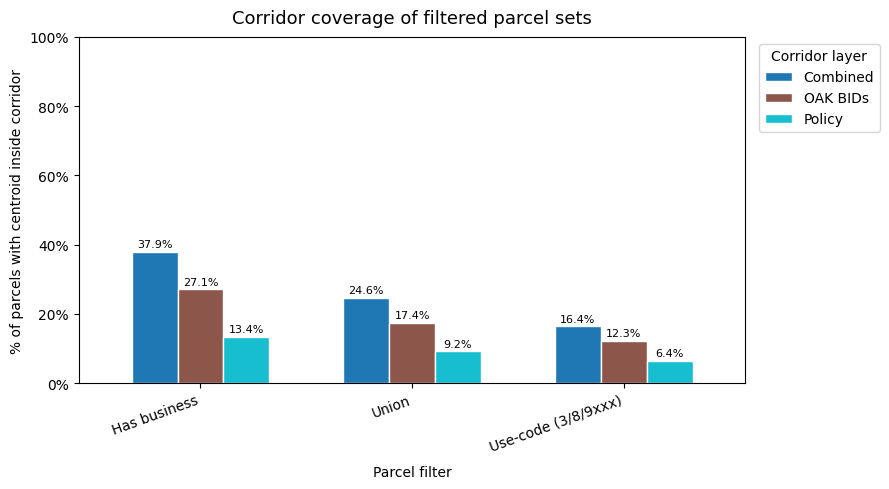

In [12]:

fig, ax = plt.subplots(figsize=(9, 5))

pivot_pct.T.plot(
    kind="bar",
    ax=ax,
    width=0.65,
    colormap="tab10",
    edgecolor="white",
)

ax.set_title("Corridor coverage of filtered parcel sets", fontsize=13, pad=10)
ax.set_xlabel("Parcel filter", labelpad=8)
ax.set_ylabel("% of parcels with centroid inside corridor")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="Corridor layer", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 100)

# Annotate each bar with its value
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="edge", fontsize=8, padding=2)

plt.tight_layout()
plt.show()



## 2.8 Spatial Map — Corridors vs. Union Parcels

A quick map to visualise which parts of the East Bay the corridor layers cover
relative to the full union parcel set.  Parcel centroids are plotted as grey
dots; corridor outlines are overlaid on top.


In [14]:

# Pre-compute union parcel centroids (used in map and Section 3)
union_centroids = parcels_union.copy()
union_centroids["geometry"] = parcels_union.geometry.centroid


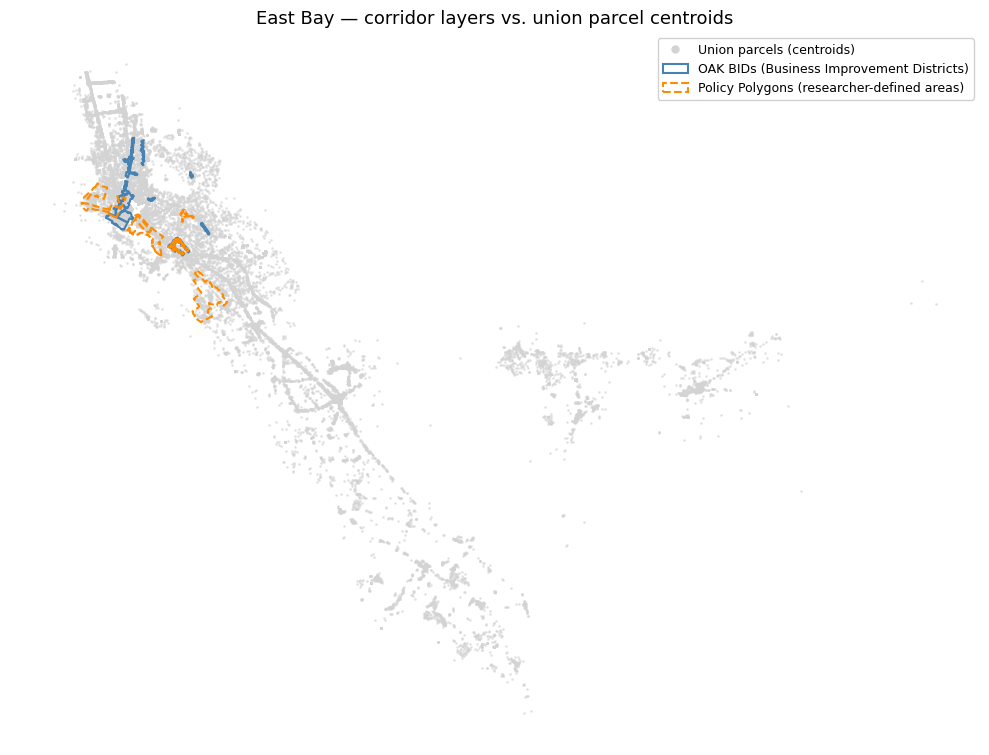

In [15]:

fig, ax = plt.subplots(figsize=(10, 10))

# Plot union parcel centroids as light grey dots
union_centroids.plot(ax=ax, color="lightgrey", markersize=1, alpha=0.5)

# OAK BIDs — solid blue outlines
oak_bids.plot(ax=ax, facecolor="none", edgecolor="steelblue", linewidth=1.5)

# Policy Polygons — dashed orange outlines
policy.plot(ax=ax, facecolor="none", edgecolor="darkorange", linewidth=1.5, linestyle="--")

legend_handles = [
    mlines.Line2D([], [], color="lightgrey", marker="o", linestyle="None",
                  markersize=5, label="Union parcels (centroids)"),
    mpatches.Patch(facecolor="none", edgecolor="steelblue", linewidth=1.5,
                   label="OAK BIDs (Business Improvement Districts)"),
    mpatches.Patch(facecolor="none", edgecolor="darkorange", linewidth=1.5,
                   linestyle="--", label="Policy Polygons (researcher-defined areas)"),
]

ax.set_title("East Bay — corridor layers vs. union parcel centroids", fontsize=13)
ax.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()
plt.show()



# Section 3 — Exploratory Corridor Methodology

The existing BID and Policy Polygon boundaries capture **< 40 %** of the filtered parcel set
(Section 2), which confirms that a more data-driven approach is needed.

This section explores three starter methodologies, each representing a different philosophical
frame for what a "corridor" is.  A guiding design constraint throughout is **geographic
distribution**: the goal is approximately **25 corridors spread across the full East Bay**,
not a concentration in the highest-density areas (downtown Oakland).  Each approach is adapted
to work toward that target.

| # | Approach | Core idea | Distribution strategy |
|---|---|---|---|
| **3.1** | DBSCAN business clustering | A corridor is a *dense concentration of businesses* | Sub-region stratification: run DBSCAN independently per zone |
| **3.2** | Grid-density thresholding | A corridor is a *high-activity zone* on a regular grid | Local-relative threshold: active cells defined per sub-region percentile |
| **3.3** | Parcel-connectivity blobs | A corridor is a *contiguous island of commercial land* | Greedy spatial-diversity selection from 100+ candidate blobs |

None of these is a final answer.  The goal is to surface candidate geometries distributed
across the region that can seed a richer, participatory definition — one where geography,
community recognition, and economic activity are all balanced.



## 3.1 Approach A — DBSCAN Clustering of Business Locations (Sub-region Stratified)

**Idea:** Run DBSCAN on business point coordinates to identify dense clusters.  A single
global run, however, is dominated by downtown Oakland — the study area's highest-density zone —
and produces a handful of large clusters there while leaving the rest of the East Bay
unrepresented.

To address this, the study bounding box is divided into a `SUBREGION_ROWS × SUBREGION_COLS`
geographic grid.  DBSCAN is run **independently within each zone** and the resulting clusters
are merged.  This means that a commercial node in Hayward or Fruitvale is evaluated against
its *local* business density, not against downtown Oakland — ensuring detection across the
full region.

Each cluster's footprint is built as a union of small buffers around its member points,
producing an organic shape that conforms to street-level concentrations.

**Parameters:**

| Parameter | Value | Meaning |
|---|---|---|
| Sub-region grid | 3 × 2 | Geographic zones within which DBSCAN runs independently |
| `eps` | 200 m | Neighbourhood radius — how close two businesses must be |
| `min_samples` | 8 | Minimum neighbours to form a core point |
| Point buffer | 80 m | Buffer applied per point to build the cluster footprint |
| Min cluster size | 15 businesses | Discard trivially small clusters |


In [17]:

# ── Sub-region stratified DBSCAN ──────────────────────────────────────────────
# Divide the study bounding box into SUBREGION_ROWS × SUBREGION_COLS zones.
# Use parcels_union bounds (Alameda County extent) — not businesses_gdf bounds,
# which may span a wider area and collapse all local businesses into one zone.
# Running DBSCAN within each zone prevents downtown density from swamping
# smaller commercial nodes elsewhere in the East Bay.

minx_b, miny_b, maxx_b, maxy_b = parcels_union.total_bounds
row_h_a = (maxy_b - miny_b) / SUBREGION_ROWS
col_w_a = (maxx_b - minx_b) / SUBREGION_COLS

all_polys    = []
zone_summary = []

for r in range(SUBREGION_ROWS):
    for c in range(SUBREGION_COLS):
        x0, x1 = minx_b + c * col_w_a,     minx_b + (c + 1) * col_w_a
        y0, y1 = miny_b + r * row_h_a,     miny_b + (r + 1) * row_h_a
        zone   = f"r{r}c{c}"

        mask = (
            (businesses_gdf.geometry.x >= x0) & (businesses_gdf.geometry.x < x1) &
            (businesses_gdf.geometry.y >= y0) & (businesses_gdf.geometry.y < y1)
        )
        sub = businesses_gdf[mask].copy()

        if len(sub) < DBSCAN_MIN_SAMPLES * 2:
            zone_summary.append({"zone": zone, "n_biz": len(sub), "clusters": 0, "noise_pct": None})
            continue

        coords_sub = np.column_stack([sub.geometry.x, sub.geometry.y])
        db_sub = DBSCAN(eps=DBSCAN_EPS_M, min_samples=DBSCAN_MIN_SAMPLES,
                        algorithm="ball_tree", metric="euclidean").fit(coords_sub)
        sub = sub.copy()
        sub["_lbl"] = db_sub.labels_

        n_kept = 0
        for cid in sorted(set(db_sub.labels_[db_sub.labels_ >= 0])):
            pts = sub[sub["_lbl"] == cid]["geometry"]
            if len(pts) < DBSCAN_MIN_CLUSTER_N:
                continue
            footprint = unary_union([p.buffer(DBSCAN_BIZ_BUFFER_M) for p in pts])
            all_polys.append({"n_businesses": len(pts), "zone": zone, "geometry": footprint})
            n_kept += 1

        noise_frac = (db_sub.labels_ == -1).mean() * 100
        zone_summary.append({"zone": zone, "n_biz": len(sub), "clusters": n_kept,
                              "noise_pct": round(noise_frac, 1)})

dbscan_corridors = gpd.GeoDataFrame(all_polys, crs=PARCEL_CRS).reset_index(drop=True)

print(f"Sub-region breakdown ({SUBREGION_ROWS}×{SUBREGION_COLS} grid, Alameda County extent):")
for zs in zone_summary:
    noise_str = f", noise={zs['noise_pct']}%" if zs["noise_pct"] is not None else " (too sparse)"
    print(f"  {zs['zone']:6s}:  {zs['n_biz']:>6,} businesses → {zs['clusters']} clusters{noise_str}")

print(f"\nTotal clusters across all zones : {len(dbscan_corridors)}")
print(f"\nTop clusters by business count:")
print(dbscan_corridors.sort_values("n_businesses", ascending=False)
      [["zone", "n_businesses"]].head(12).to_string(index=False))


Sub-region breakdown (3×2 grid, Alameda County extent):
  r0c0  :       0 businesses → 0 clusters (too sparse)
  r0c1  :       0 businesses → 0 clusters (too sparse)
  r1c0  :   2,280 businesses → 13 clusters, noise=14.3%
  r1c1  :       0 businesses → 0 clusters (too sparse)
  r2c0  :  27,263 businesses → 36 clusters, noise=4.9%
  r2c1  :       0 businesses → 0 clusters (too sparse)

Total clusters across all zones : 49

Top clusters by business count:
zone  n_businesses
r2c0         22805
r1c0           581
r2c0           406
r1c0           283
r2c0           240
r2c0           240
r2c0           190
r1c0           171
r2c0           168
r1c0           167
r2c0           158
r1c0           154


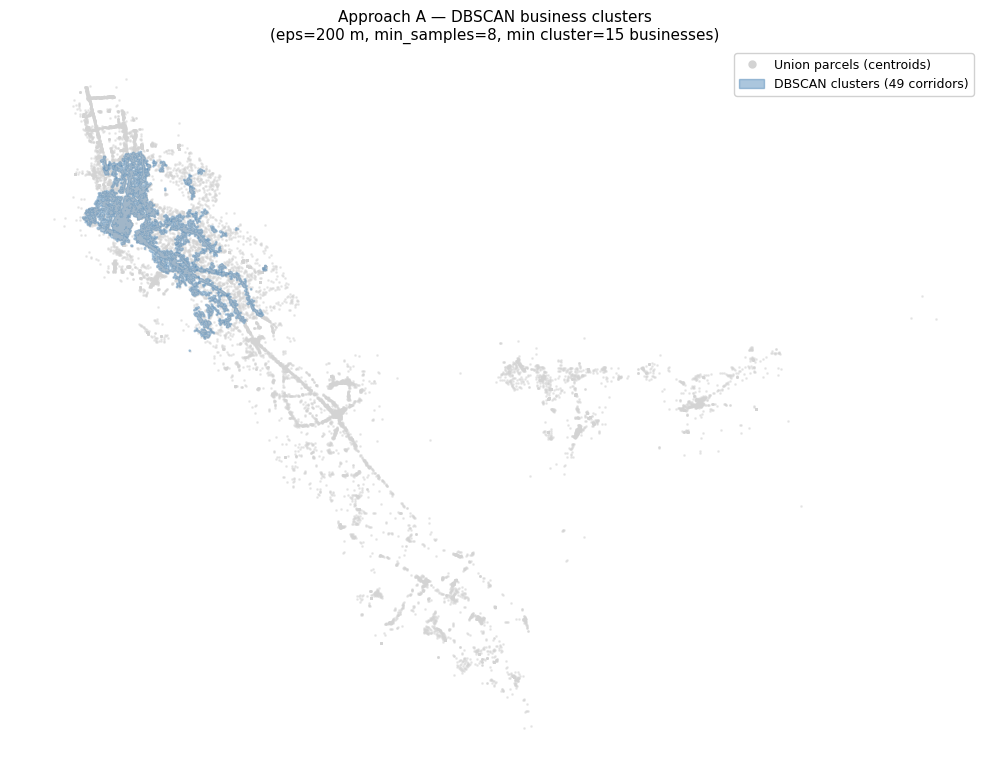

In [18]:

# ── Map: DBSCAN candidate corridors ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

union_centroids.plot(ax=ax, color="lightgrey", markersize=1, alpha=0.4)

dbscan_corridors.plot(ax=ax, facecolor="steelblue", alpha=0.35,
                      edgecolor="steelblue", linewidth=0.8)

legend_handles = [
    mlines.Line2D([], [], color="lightgrey", marker="o", linestyle="None",
                  markersize=5, label="Union parcels (centroids)"),
    mpatches.Patch(facecolor="steelblue", alpha=0.45, edgecolor="steelblue",
                   label=f"DBSCAN clusters ({len(dbscan_corridors)} corridors)"),
]

ax.set_title(f"Approach A — DBSCAN business clusters\n"
             f"(eps={DBSCAN_EPS_M} m, min_samples={DBSCAN_MIN_SAMPLES}, "
             f"min cluster={DBSCAN_MIN_CLUSTER_N} businesses)", fontsize=11)
ax.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()
plt.show()



### Approach A — Assessment

Sub-region stratification successfully pulls more clusters from the southern areas (San Leandro
corridor), but the business data reveals a fundamental geographic constraint: the DataAxle file
is Oakland-centric, with ~92% of businesses concentrated in the northern two sub-regions.
Southern and eastern zones produce few or no clusters regardless of stratification.

Within the Oakland area, the sub-region approach does separate northern from southern Oakland —
but the core flatlands (downtown to Fruitvale) still produce a single massive cluster
(~22,800 businesses) that no single-scale DBSCAN can meaningfully subdivide.

| | |
|---|---|
| ✅ **Locally data-driven** | Sub-region clusters reflect local density, not just global rankings |
| ✅ **Detects density, not just presence** | Isolated businesses don't become corridors; co-location is required |
| ✅ **Shape follows street patterns** | The buffered-union footprint conforms naturally to block structure |
| ⚠️ **Bounded by data coverage** | Oakland-centric business data means most sub-regions are empty — not a methodology failure, but a data gap |
| ⚠️ **Mega-cluster problem** | The contiguous commercial fabric of the Oakland flatlands merges into one giant cluster at any eps scale practical for outlying areas |
| ⚠️ **Parameter sensitivity** | `eps` and `min_samples` require simultaneous tuning across sub-regions with very different densities |
| ⚠️ **No sense of identity** | Clusters with similar density profiles are geometrically interchangeable — community character is invisible |



## 3.2 Approach B — Grid-Density Thresholding (Local-Relative)

**Idea:** Overlay a regular square grid and count businesses per cell.  A global absolute
threshold systematically favours dense areas: downtown Oakland cells can hold hundreds of
businesses while a legitimate corridor in San Leandro might only have five, making any
threshold that captures downtown exclude the south entirely.

To correct for this, each cell is evaluated against the distribution of cells **within its own
sub-region** (the same `SUBREGION_ROWS × SUBREGION_COLS` grid as Approach A).  A cell is
"active" if its count places it in the top `(100 − GRID_PERCENTILE)%` of cells in that zone,
subject to an absolute floor of `GRID_BIZ_THRESHOLD`.  This means a cell in Hayward needs
only to be *locally* dense — not competitive with downtown — to qualify.

Adjacent active cells are dissolved into blobs; blobs below `GRID_MIN_CELLS` are dropped.

**Parameters:**

| Parameter | Value | Meaning |
|---|---|---|
| Sub-region grid | 3 × 2 | Zones within which the local percentile is computed |
| Cell size | 350 m | Spatial resolution of the grid |
| Local percentile threshold | 70th (per sub-region) | Keep cells in top 30% of their zone |
| Absolute floor | ≥ 4 businesses | Prevents near-empty cells from qualifying in sparse zones |
| Min cells per blob | 3 | Discard isolated single-cell spikes |


In [19]:

# ── Build fishnet grid over Alameda County parcel extent ─────────────────────
# Use parcels_union bounds (not businesses_gdf which may span a wider area).
minx, miny, maxx, maxy = parcels_union.total_bounds
cs      = GRID_CELL_SIZE_M
row_h_g = (maxy - miny) / SUBREGION_ROWS
col_w_g = (maxx - minx) / SUBREGION_COLS

xs    = np.arange(minx, maxx + cs, cs)
ys    = np.arange(miny, maxy + cs, cs)
cells = [box(x, y, x + cs, y + cs) for x in xs for y in ys]

grid = gpd.GeoDataFrame({"cell_id": range(len(cells))}, geometry=cells, crs=PARCEL_CRS)

# ── Count businesses per cell ─────────────────────────────────────────────────
biz_in_cells = gpd.sjoin(businesses_gdf[["geometry"]], grid, how="inner", predicate="within")
cell_counts  = biz_in_cells.groupby("cell_id").size().rename("biz_count")
grid = grid.merge(cell_counts, on="cell_id", how="left").fillna({"biz_count": 0})
grid["biz_count"] = grid["biz_count"].astype(int)

# ── Assign each cell to a sub-region ─────────────────────────────────────────
cx = grid.geometry.centroid.x
cy = grid.geometry.centroid.y
grid["subregion"] = "unassigned"
for r in range(SUBREGION_ROWS):
    for c in range(SUBREGION_COLS):
        x0 = minx + c * col_w_g;  x1 = x0 + col_w_g
        y0 = miny + r * row_h_g;  y1 = y0 + row_h_g
        mask = (cx >= x0) & (cx < x1) & (cy >= y0) & (cy < y1)
        grid.loc[mask, "subregion"] = f"r{r}c{c}"

# ── Local-percentile threshold: top (100−GRID_PERCENTILE)% within each zone ──
# with an absolute floor of GRID_BIZ_THRESHOLD to guard sparse sub-regions.
def local_active(grp):
    local_thresh = np.percentile(grp["biz_count"], GRID_PERCENTILE)
    thresh = max(GRID_BIZ_THRESHOLD, local_thresh)
    return grp[grp["biz_count"] >= thresh]

nonzero = grid[grid["biz_count"] > 0].copy()
active  = nonzero.groupby("subregion", group_keys=False).apply(local_active).copy()

print(f"Active cells (local top {100 - GRID_PERCENTILE}% per sub-region, floor ≥{GRID_BIZ_THRESHOLD}):")
for zone, grp in nonzero.groupby("subregion"):
    local_thresh = max(GRID_BIZ_THRESHOLD, np.percentile(grp["biz_count"], GRID_PERCENTILE))
    n_active = (grp["biz_count"] >= local_thresh).sum()
    print(f"  {zone}: local threshold={local_thresh:.0f} businesses, active cells={n_active}")
print(f"Total active cells: {len(active):,}")

# ── Dissolve neighbours into blobs, filter small ones ────────────────────────
active_dissolved = (
    active.dissolve()
    .explode(index_parts=False)
    .reset_index(drop=True)
    .rename_axis("blob_id")
    .reset_index()
)

cell_centroids   = active.copy()
cell_centroids["geometry"] = active.geometry.centroid
blob_cell_counts = gpd.sjoin(
    cell_centroids[["geometry"]],
    active_dissolved[["blob_id", "geometry"]],
    how="inner", predicate="within",
).groupby("blob_id").size().rename("n_cells")

active_dissolved = active_dissolved.merge(blob_cell_counts, on="blob_id", how="left").fillna(0)
active_dissolved["n_cells"] = active_dissolved["n_cells"].astype(int)
grid_corridors = active_dissolved[active_dissolved["n_cells"] >= GRID_MIN_CELLS].copy()

print(f"\nDissolved blobs                        : {len(active_dissolved)}")
print(f"Blobs after min-cell filter            : {len(grid_corridors)}")
print(f"\nBlob sizes (cells):")
print(grid_corridors["n_cells"].describe().round(1))


Active cells (local top 30% per sub-region, floor ≥4):
  r1c0: local threshold=8 businesses, active cells=71
  r2c0: local threshold=12 businesses, active cells=361
Total active cells: 432

Dissolved blobs                        : 64
Blobs after min-cell filter            : 19

Blob sizes (cells):
count     19.0
mean      19.8
std       43.3
min        3.0
25%        3.0
50%        5.0
75%       12.5
max      191.0
Name: n_cells, dtype: float64


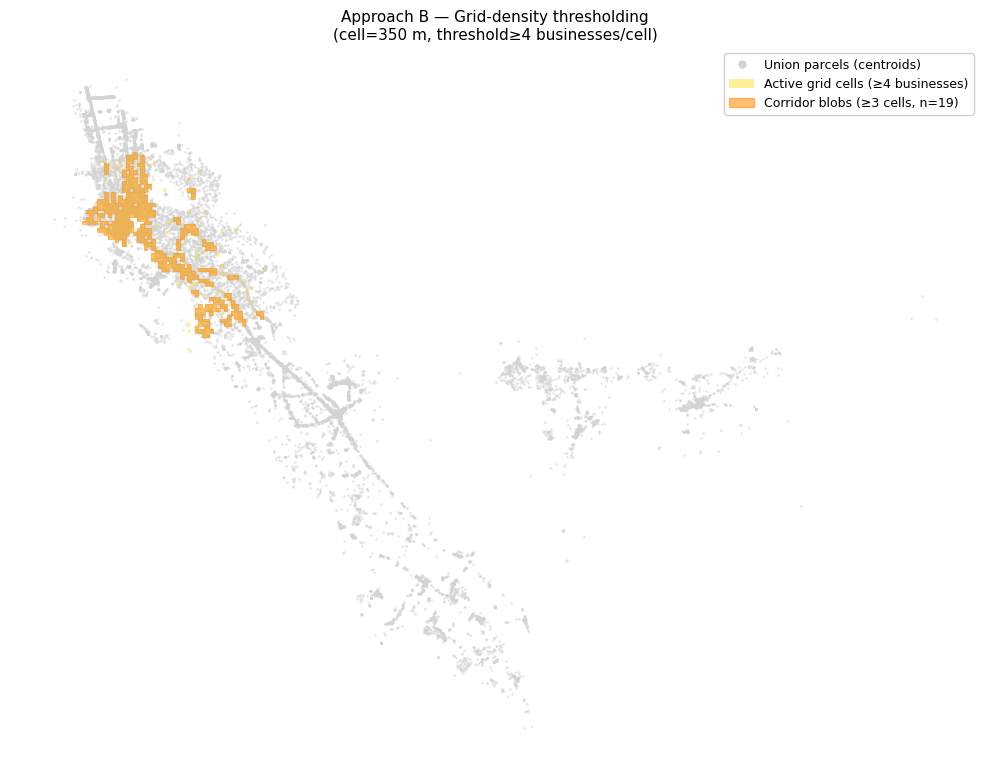

In [20]:

# ── Map: grid-density candidate corridors ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

union_centroids.plot(ax=ax, color="lightgrey", markersize=1, alpha=0.4)

# Show all active cells lightly for context
active.plot(ax=ax, facecolor="gold", alpha=0.25, edgecolor="none")

# Corridor blobs (multi-cell) with stronger fill
grid_corridors.plot(ax=ax, facecolor="darkorange", alpha=0.45,
                    edgecolor="darkorange", linewidth=0.8)

legend_handles = [
    mlines.Line2D([], [], color="lightgrey", marker="o", linestyle="None",
                  markersize=5, label="Union parcels (centroids)"),
    mpatches.Patch(facecolor="gold", alpha=0.4, edgecolor="none",
                   label=f"Active grid cells (≥{GRID_BIZ_THRESHOLD} businesses)"),
    mpatches.Patch(facecolor="darkorange", alpha=0.55, edgecolor="darkorange",
                   label=f"Corridor blobs (≥{GRID_MIN_CELLS} cells, n={len(grid_corridors)})"),
]

ax.set_title(f"Approach B — Grid-density thresholding\n"
             f"(cell={GRID_CELL_SIZE_M} m, threshold≥{GRID_BIZ_THRESHOLD} businesses/cell)", fontsize=11)
ax.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()
plt.show()



### Approach B — Assessment

| | |
|---|---|
| ✅ **Highly transparent** | A cell is "active" or not based on a single, legible threshold — easy to explain and audit |
| ✅ **Scale-adjustable** | Changing cell size shifts between fine-grained block-level and coarser neighbourhood-level results |
| ✅ **Stable to business turnover** | Adding/removing a handful of businesses rarely flips a cell's status |
| ⚠️ **Grid alignment is arbitrary** | Shifting the grid origin by 50 m can redraw corridor boundaries substantially (the "MAUP") |
| ⚠️ **Rectangular blobs** | Grid cells produce boxy corridor shapes that rarely match the organic form of a commercial street |
| ⚠️ **Misses linear corridors** | A long commercial strip with moderate density can fall below per-cell thresholds even though it functions as a coherent corridor |
| ⚠️ **Business count only** | Like Approach A, this knows nothing about parcel use, property type, or community identity |



## 3.3 Approach C — Parcel-Connectivity Blobs with Spatial-Diversity Selection

**Idea:** Start from the *union parcel set* — parcels that are either commercially zoned or
contain a business.  A small buffer bridges narrow gaps across streets and alleys; dissolving
produces connected "blobs" of commercial land.  Islands below `BLOB_MIN_PARCELS` are pruned.

Unlike Approaches A and B, this method already produces **well-distributed results** across
the East Bay — because commercial land is spread throughout the region regardless of current
business density.  The challenge is the opposite: it yields ~100 blobs, far more than needed.

The addition here is a **greedy spatial-diversity selection** step.  Each blob is scored by a
combination of parcel count and business density.  Starting from the highest-scoring blob, the
algorithm iteratively adds the next best candidate only if its centroid is at least
`MIN_SPACING_M` away from all already-selected corridors.  This produces ~`TARGET_CORRIDORS`
selections that are both high-quality *and* geographically spread.

**Parameters:**

| Parameter | Value | Meaning |
|---|---|---|
| Connect buffer | 40 m | Gap-closing distance between adjacent parcels |
| Min parcels per blob | 25 | Discard tiny isolated commercial lots |
| Target corridors | 25 | Number of corridors to select from candidates |
| Min spacing | 3,000 m | Minimum centroid-to-centroid distance between selections |


In [21]:

# ── Buffer → dissolve → explode into individual connected blobs ───────────────
buffered  = parcels_union.geometry.buffer(PARCEL_CONNECT_BUF_M)
dissolved = unary_union(buffered)

parcel_blobs = (
    gpd.GeoDataFrame(geometry=[dissolved], crs=PARCEL_CRS)
    .explode(index_parts=False)
    .reset_index(drop=True)
    .rename_axis("blob_id")
    .reset_index()
)

# ── Count union parcels per blob ──────────────────────────────────────────────
blob_join = gpd.sjoin(
    union_centroids[["geometry"]],
    parcel_blobs[["blob_id", "geometry"]],
    how="inner", predicate="within",
)
blob_parcel_counts = blob_join.groupby("blob_id").size().rename("parcel_count")
parcel_blobs = parcel_blobs.merge(blob_parcel_counts, on="blob_id", how="left").fillna(0)
parcel_blobs["parcel_count"] = parcel_blobs["parcel_count"].astype(int)

# ── Count businesses per blob ─────────────────────────────────────────────────
biz_join = gpd.sjoin(
    businesses_gdf[["geometry"]],
    parcel_blobs[["blob_id", "geometry"]],
    how="inner", predicate="within",
)
blob_biz_counts = biz_join.groupby("blob_id").size().rename("biz_count")
parcel_blobs = parcel_blobs.merge(blob_biz_counts, on="blob_id", how="left").fillna(0)
parcel_blobs["biz_count"] = parcel_blobs["biz_count"].astype(int)

# ── Negative-buffer to remove artificial expansion, then filter ───────────────
parcel_blobs["geometry"] = parcel_blobs.geometry.buffer(-PARCEL_CONNECT_BUF_M)
connectivity_corridors = parcel_blobs[parcel_blobs["parcel_count"] >= BLOB_MIN_PARCELS].copy()

# ── Score each blob: balance parcel count and business density ────────────────
connectivity_corridors = connectivity_corridors.copy()
connectivity_corridors["biz_density"] = (
    connectivity_corridors["biz_count"] / connectivity_corridors["parcel_count"].clip(lower=1)
)
connectivity_corridors["score"] = (
    np.log(connectivity_corridors["parcel_count"]) +
    np.log1p(connectivity_corridors["biz_count"])
)

# ── Greedy spatial-diversity selection ───────────────────────────────────────
# Iterates through blobs in score order; selects each only if its centroid is
# at least MIN_SPACING_M from all already-selected corridor centroids.
candidates        = connectivity_corridors.sort_values("score", ascending=False).copy()
cand_centroids    = candidates.geometry.centroid
selected_idx      = []
selected_cents    = []

for idx, row in candidates.iterrows():
    c = cand_centroids[idx]
    if all(c.distance(s) >= MIN_SPACING_M for s in selected_cents):
        selected_idx.append(idx)
        selected_cents.append(c)
    if len(selected_idx) >= TARGET_CORRIDORS:
        break

selected_corridors = connectivity_corridors.loc[selected_idx].copy()

print(f"Total blobs after dissolve            : {len(parcel_blobs):,}")
print(f"Blobs ≥ {BLOB_MIN_PARCELS} parcels (candidates)  : {len(connectivity_corridors)}")
print(f"Selected corridors (spatial spread)   : {len(selected_corridors)}")
print(f"\nSelected corridor stats:")
print(selected_corridors[["parcel_count", "biz_count", "biz_density"]].describe().round(1))


Total blobs after dissolve            : 1,845
Blobs ≥ 25 parcels (candidates)  : 101
Selected corridors (spatial spread)   : 25

Selected corridor stats:
       parcel_count  biz_count  biz_density
count          25.0       25.0         25.0
mean          700.4      914.2          0.7
std          2003.3     3580.8          1.2
min            26.0        0.0          0.0
25%            88.0        0.0          0.0
50%           146.0        0.0          0.0
75%           311.0      224.0          1.0
max         10121.0    18010.0          4.5


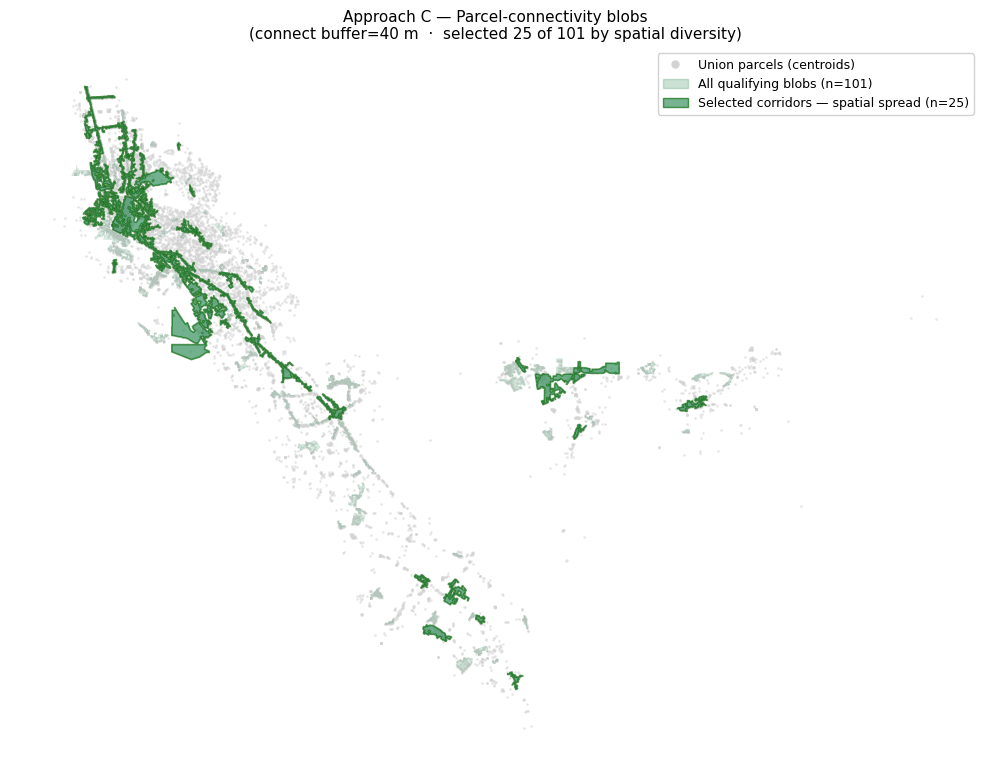

In [22]:

# ── Map: parcel-connectivity candidate corridors ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

union_centroids.plot(ax=ax, color="lightgrey", markersize=1, alpha=0.4)

# All qualifying blobs in light green for context
connectivity_corridors.plot(ax=ax, facecolor="seagreen", alpha=0.18,
                            edgecolor="seagreen", linewidth=0.4)

# Selected ~25 with stronger fill and darker outline
selected_corridors.plot(ax=ax, facecolor="seagreen", alpha=0.60,
                        edgecolor="darkgreen", linewidth=1.2)

legend_handles = [
    mlines.Line2D([], [], color="lightgrey", marker="o", linestyle="None",
                  markersize=5, label="Union parcels (centroids)"),
    mpatches.Patch(facecolor="seagreen", alpha=0.25, edgecolor="seagreen",
                   label=f"All qualifying blobs (n={len(connectivity_corridors)})"),
    mpatches.Patch(facecolor="seagreen", alpha=0.65, edgecolor="darkgreen",
                   label=f"Selected corridors — spatial spread (n={len(selected_corridors)})"),
]

ax.set_title(f"Approach C — Parcel-connectivity blobs\n"
             f"(connect buffer={PARCEL_CONNECT_BUF_M} m  ·  "
             f"selected {len(selected_corridors)} of {len(connectivity_corridors)} by spatial diversity)",
             fontsize=11)
ax.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()
plt.show()



### Approach C — Assessment

| | |
|---|---|
| ✅ **Grounded in land use** | Corridors reflect what land is *zoned or used* for, not just where a business currently operates |
| ✅ **Stable to business churn** | A vacated storefront doesn't remove its parcel from the corridor |
| ✅ **Naturally street-aligned** | Parcels front onto streets, so blobs tend to trace commercial thoroughfares rather than produce round blobs |
| ✅ **Combines two signals** | Both land-use codes and actual business occupancy feed the parcel filter (union set) |
| ⚠️ **Buffer distance is critical** | Too small: fragmented corridors split across a street. Too large: whole neighbourhoods merge |
| ⚠️ **Large blobs are hard to split** | Dense downtown areas may dissolve into one giant blob that isn't a single corridor |
| ⚠️ **No sense of corridor intensity** | A blob with 30 parcels looks the same as one with 300 — intensity must be added separately |



## 3.4 Side-by-Side Comparison Map

All three sets of candidate corridors shown together alongside the existing BID boundaries,
to give a quick visual read on where they agree and where they diverge.


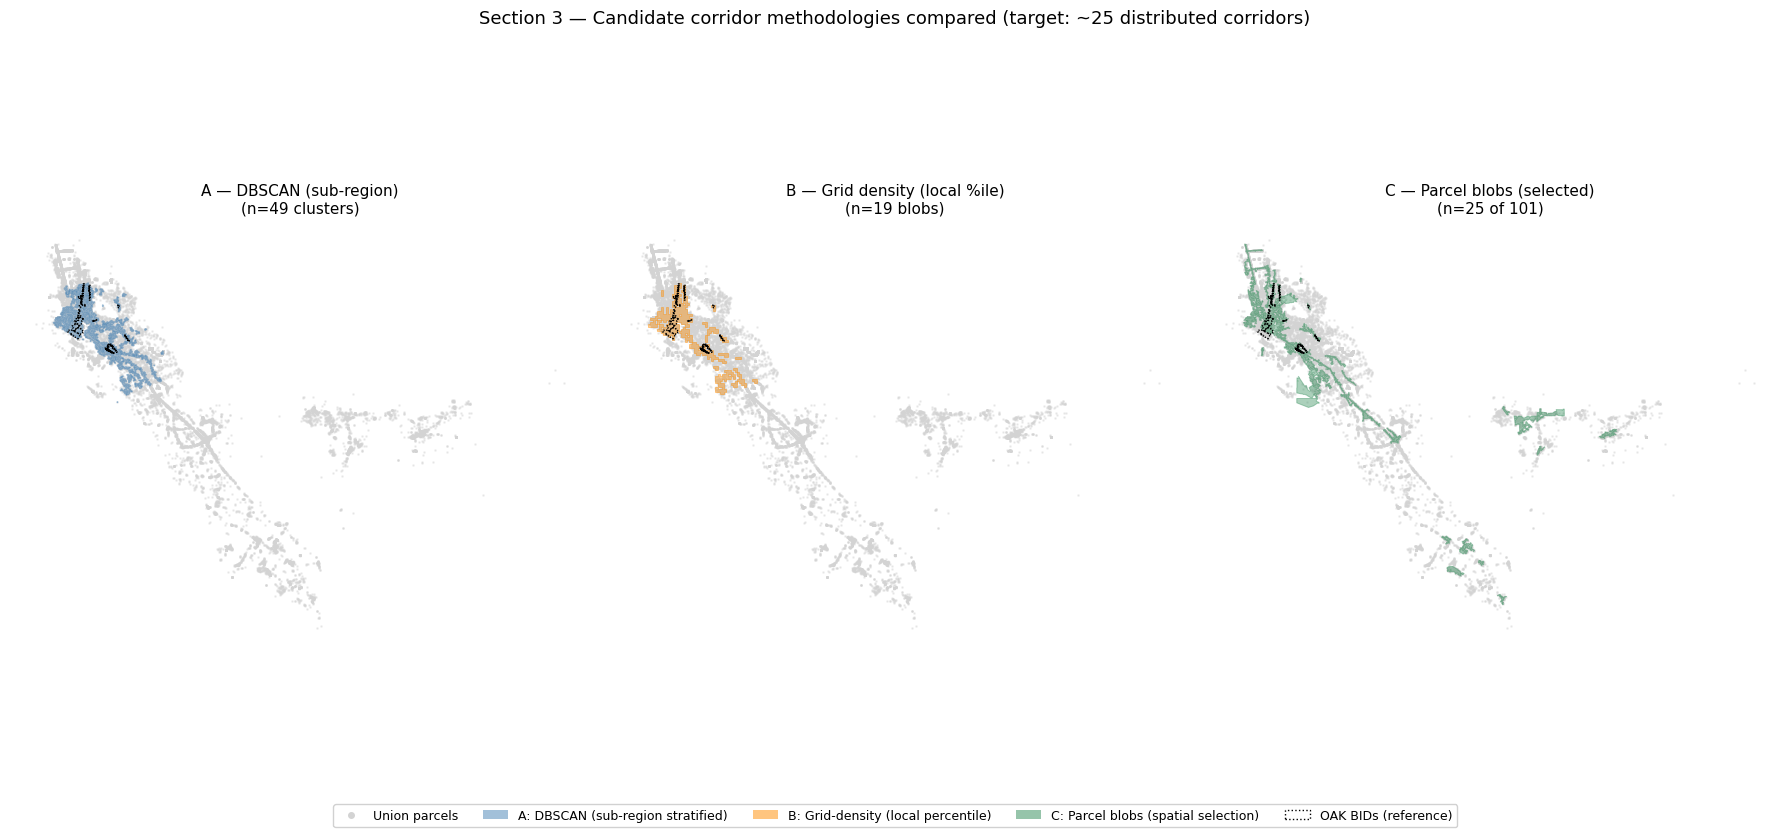

In [23]:

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

configs = [
    (axes[0], dbscan_corridors,    "steelblue",
     f"A — DBSCAN (sub-region)\n(n={len(dbscan_corridors)} clusters)"),
    (axes[1], grid_corridors,      "darkorange",
     f"B — Grid density (local %ile)\n(n={len(grid_corridors)} blobs)"),
    (axes[2], selected_corridors,  "seagreen",
     f"C — Parcel blobs (selected)\n(n={len(selected_corridors)} of {len(connectivity_corridors)})"),
]

for ax, corridors, colour, title in configs:
    union_centroids.plot(ax=ax, color="lightgrey", markersize=0.8, alpha=0.35)
    corridors.plot(ax=ax, facecolor=colour, alpha=0.40, edgecolor=colour, linewidth=0.7)
    # OAK BIDs for reference in each panel
    oak_bids.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.0, linestyle=":")
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

# Shared legend
shared_handles = [
    mlines.Line2D([], [], color="lightgrey", marker="o", linestyle="None",
                  markersize=4, label="Union parcels"),
    mpatches.Patch(facecolor="steelblue",  alpha=0.5, label="A: DBSCAN (sub-region stratified)"),
    mpatches.Patch(facecolor="darkorange", alpha=0.5, label="B: Grid-density (local percentile)"),
    mpatches.Patch(facecolor="seagreen",   alpha=0.5, label="C: Parcel blobs (spatial selection)"),
    mpatches.Patch(facecolor="none", edgecolor="black", linewidth=1.0,
                   linestyle=":", label="OAK BIDs (reference)"),
]
fig.legend(handles=shared_handles, loc="lower center", ncol=5, fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Section 3 — Candidate corridor methodologies compared (target: ~25 distributed corridors)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()



## 3.5 Observations & Recommended Path Forward

### What the revised approaches tell us

With geographic distribution built into each method, the three approaches now offer
complementary views rather than all converging on downtown Oakland:

* **DBSCAN (sub-region stratified)** detects commercially active clusters in each geographic
  zone independently.  It is best at identifying *where businesses actually concentrate* at a
  local level, but corridor shapes are still volatile and sensitive to the `eps` parameter.
  Zones with low overall business density may produce few or no clusters regardless of
  stratification.

* **Grid density (local percentile)** surfaces the *relatively busiest cells* in each part of
  the region.  The normalisation makes it more equitable across the East Bay, but the
  rectangular geometry and the arbitrary grid origin remain limitations — a commercial strip
  that straddles a cell boundary can be artificially split.

* **Parcel connectivity + spatial selection** provides the most actionable output.  The full
  blob layer already traces commercial land across the region; the greedy selection produces a
  set of ~25 corridors that are both high-quality (scored by parcel count and business
  density) and geographically spread (enforced minimum spacing).  This is the closest of the
  three to a working first draft of corridor boundaries.

### Key tensions to resolve

1. **Scale vs. granularity** — A 3 km minimum spacing forces spread but may skip over a
   legitimate secondary corridor adjacent to a major one (e.g. two parallel commercial
   streets in East Oakland).  This parameter should be discussed with the team.

2. **Density vs. land use** — Approaches A and B measure *current business activity*;
   Approach C measures *commercial land structure*.  A corridor with many parcels but few
   active businesses may be declining or transitional — worth distinguishing, not ignoring.

3. **The downtown problem is structural** — Even with sub-region stratification and spatial
   selection, downtown Oakland and the central Oakland flatlands contain the most commercial
   land and the most businesses.  Any purely data-driven method will weight these areas
   heavily.  A community input step will be needed to ensure that smaller, community-anchored
   corridors (e.g. a single main street in San Leandro) are not underrepresented.

### Recommended next step

Use **Approach C's selected corridors** as the working spatial skeleton for the next
discussion.  For each selected corridor blob, bring in:
- Business count and industry mix (from DataAxle) → *economic character*
- Parcel use-code breakdown → *land-use character*
- Proximity to existing BIDs or Policy Polygons → *alignment with established boundaries*

This profile will allow the team to evaluate whether each blob feels like a coherent
corridor, where blobs should be split or merged, and which areas of the East Bay are
currently underrepresented.
